In [1]:
import csv

# Read CSV file
with open("outagesNYISO.csv") as file:
    csv_reader = csv.DictReader(file)
    data = list(csv_reader)

In [2]:
len(data)

45178

In [3]:
data[0]

{'OutageID': '2',
 'PTID': '26007',
 'Name': 'GOWANUSA-GREENWD__138_42G24',
 'OutDatetime': 'DateObject[{2008, 11, 1, 0, 12, 0.}, "Instant", "Gregorian", "America/New_York"]',
 'MinTimeStamp': 'DateObject[{2008, 11, 1, 0, 17, 18.}, "Instant", "Gregorian", "America/New_York"]',
 'MaxTimeStamp': 'DateObject[{2008, 11, 2, 23, 57, 19.}, "Instant", "Gregorian", "America/New_York"]',
 'NearestSCtime': 'DateObject[{2008, 11, 1, 0, 12, 17.}, "Instant", "Gregorian", "America/New_York"]',
 'TimeDifferencefromScheduled': '0.2833333333333333',
 'OutageType': 'Planned',
 'DurationBAD': '2865.3166666666666',
 'LineNameOLD': '{"GOWANUSA", "GREENWD", 1}',
 'Voltage': '138',
 'BusNames': '{"GOWANUSA", "GREENWD"}',
 'UnitNumber': '1',
 'LineName': '{"GOWANUSA", "GREENWD", 1}',
 'OutAbstime': '3434501520',
 'TimeZone': 'EPT'}

In [4]:
import re
from datetime import datetime, timedelta
from zoneinfo import ZoneInfo


PATTERN = re.compile(
    r"^DateObject\[\{\s*"
    r"(?P<year>-?\d+)\s*,\s*"
    r"(?P<month>\d+)\s*,\s*"
    r"(?P<day>\d+)\s*,\s*"
    r"(?P<hour>\d+)\s*,\s*"
    r"(?P<minute>\d+)\s*,\s*"
    r"(?P<second>\d+(?:\.\d*)?)\s*"
    r'\}\s*,\s*"[^"]*"\s*,\s*"[^"]*"\s*,\s*"(?P<tz>[^"]+)"\s*\]$'
)


def parse_dateobject(s: str) -> datetime:
    m = PATTERN.match(s.strip())
    if not m:
        raise ValueError(f"Invalid DateObject format: {s}")

    year = int(m.group("year"))
    month = int(m.group("month"))
    day = int(m.group("day"))
    hour = int(m.group("hour"))
    minute = int(m.group("minute"))
    sec_float = float(m.group("second"))  # handles 0. / 18. / 12.345
    tz = ZoneInfo(m.group("tz"))

    sec_int = int(sec_float)
    micro = int(round((sec_float - sec_int) * 1_000_000))
    if micro == 1_000_000:  # rounding edge case
        sec_int += 1
        micro = 0

    dt = datetime(year, month, day, hour, minute, 0, 0, tzinfo=tz)
    dt += timedelta(seconds=sec_int, microseconds=micro)
    return dt

In [5]:
for datum in data:
    datum["OutDatetime"] = parse_dateobject(datum["OutDatetime"])
    datum["MinTimeStamp"] = parse_dateobject(datum["MinTimeStamp"])
    datum["MaxTimeStamp"] = parse_dateobject(datum["MaxTimeStamp"])

In [6]:
data

[{'OutageID': '2',
  'PTID': '26007',
  'Name': 'GOWANUSA-GREENWD__138_42G24',
  'OutDatetime': datetime.datetime(2008, 11, 1, 0, 12, tzinfo=zoneinfo.ZoneInfo(key='America/New_York')),
  'MinTimeStamp': datetime.datetime(2008, 11, 1, 0, 17, 18, tzinfo=zoneinfo.ZoneInfo(key='America/New_York')),
  'MaxTimeStamp': datetime.datetime(2008, 11, 2, 23, 57, 19, tzinfo=zoneinfo.ZoneInfo(key='America/New_York')),
  'NearestSCtime': 'DateObject[{2008, 11, 1, 0, 12, 17.}, "Instant", "Gregorian", "America/New_York"]',
  'TimeDifferencefromScheduled': '0.2833333333333333',
  'OutageType': 'Planned',
  'DurationBAD': '2865.3166666666666',
  'LineNameOLD': '{"GOWANUSA", "GREENWD", 1}',
  'Voltage': '138',
  'BusNames': '{"GOWANUSA", "GREENWD"}',
  'UnitNumber': '1',
  'LineName': '{"GOWANUSA", "GREENWD", 1}',
  'OutAbstime': '3434501520',
  'TimeZone': 'EPT'},
 {'OutageID': '7',
  'PTID': '25048',
  'Name': 'JAMAICA_-VALLYSTR_138_901 L_M',
  'OutDatetime': datetime.datetime(2008, 11, 1, 1, 27, tzinfo

In [7]:
sorted_data = sorted(data, key=lambda d: d["OutDatetime"])

In [8]:
# TIME THRESHOLDS (in seconds)
SAME_GEN_THRESHOLD = 60
SAME_CASCADING_FAILURE = 3600

cascading_failures = []
current_cascade = [[sorted_data[0]]]
for datum in sorted_data[1:]:
    last_out_datetime = current_cascade[-1][-1]["OutDatetime"]
    event_out_datetime = datum["OutDatetime"]
    time_diff = (event_out_datetime - last_out_datetime).total_seconds()
    if time_diff <= SAME_GEN_THRESHOLD:
        current_cascade[-1].append(datum)
    elif time_diff <= SAME_CASCADING_FAILURE:
        current_cascade.append([datum])
    else:
        cascading_failures.append(current_cascade)
        current_cascade = [[datum]]

In [9]:
generation_sizes = [len(cascading_failure) for cascading_failure in cascading_failures]
cascading_failure_sizes = [
    sum(len(gen) for gen in cascading_failure)
    for cascading_failure in cascading_failures
]

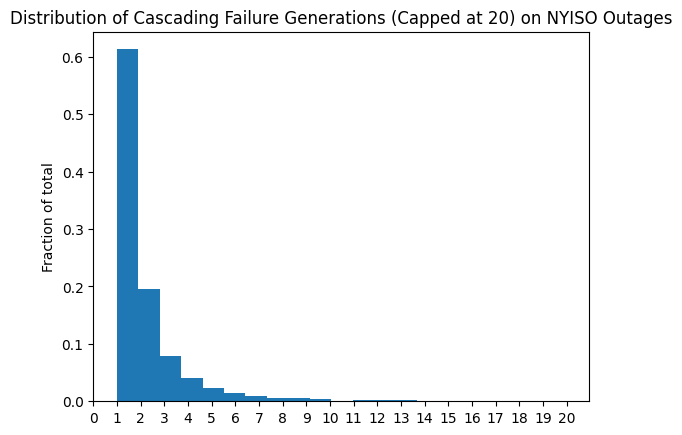

In [10]:
import matplotlib.pyplot as plt

MAX_GEN = 20
total = len(generation_sizes)
_orig_hist = plt.hist


def _hist_with_total_scaling(*args, **kwargs):
    if "weights" not in kwargs and args:
        try:
            n = len(args[0])
        except Exception:
            n = 1
        kwargs["weights"] = [1 / total] * n
    return _orig_hist(*args, **kwargs)


plt.hist = _hist_with_total_scaling
plt.ylabel("Fraction of total")
plt.hist([min(i, MAX_GEN) for i in generation_sizes], bins=MAX_GEN + 1)
plt.xticks(range(0, MAX_GEN + 1))
plt.title(
    f"Distribution of Cascading Failure Generations (Capped at {MAX_GEN}) on NYISO Outages"
)
plt.show()

In [11]:
from typing import Optional

import numpy as np
import powerlaw


def plot_log_log(
    size_list: list[int],
    xmin: Optional[int] = None,
    xmax: Optional[int] = None,
    dpi: Optional[int] = 100,
):
    """Plot CCDF and fit a powerlaw distribution line to the points

    :param size_list: list of initial failure size, cascading failure size, cascading generations, etc.
    """
    fig, ax = plt.subplots(dpi=dpi)

    # plot log-log CCDF
    n = len(size_list)
    values, counts = np.unique(size_list, return_counts=True)
    order = np.argsort(values)
    values = values[order]
    counts = counts[order]
    ccdf = np.cumsum(counts[::-1])[::-1] / n
    ax.loglog(values, ccdf, marker="o", linestyle="none")

    # fit a line
    fit = powerlaw.Fit(
        size_list,
        discrete=True,
        verbose=False,
        survival=True,
        xmin=xmin,
        xmax=xmax,
    )
    print("alpha:", fit.power_law.alpha)
    print("xmin :", fit.power_law.xmin)
    fit.power_law.plot_pdf(ax=ax, linestyle="--", label="Power-law fit")

    return ax

alpha: 5.338746403079295
xmin : 14.0


<Axes: >

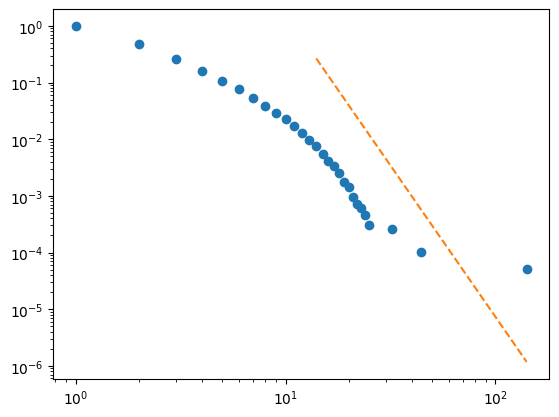

In [12]:
plot_log_log(cascading_failure_sizes)

# How many times each PTID is seen in the dataset?

Number of Part IDs: 1774


(array([6.13089755e-01, 1.94708832e-01, 7.96233753e-02, 4.11933272e-02,
        2.36925596e-02, 1.47374885e-02, 9.82499232e-03, 6.08944837e-03,
        5.21952717e-03, 3.47968478e-03, 0.00000000e+00, 1.73984239e-03,
        2.14921707e-03, 1.53515505e-03, 1.02343670e-03, 6.14062020e-04,
        3.07031010e-04, 2.04687340e-04, 4.09374680e-04, 1.02343670e-04,
        2.55859175e-04]),
 array([ 1.        ,  1.9047619 ,  2.80952381,  3.71428571,  4.61904762,
         5.52380952,  6.42857143,  7.33333333,  8.23809524,  9.14285714,
        10.04761905, 10.95238095, 11.85714286, 12.76190476, 13.66666667,
        14.57142857, 15.47619048, 16.38095238, 17.28571429, 18.19047619,
        19.0952381 , 20.        ]),
 <BarContainer object of 21 artists>)

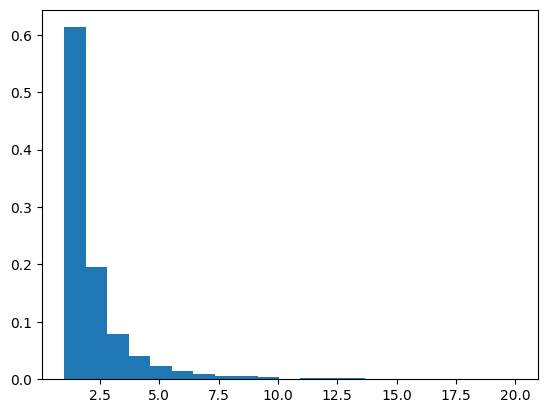

In [16]:
from collections import Counter

ptid_list = [datum["PTID"] for datum in data]
ptid_set = set(ptid_list)
print(f"Number of Part IDs: {len(ptid_set)}")
ptid_counts = Counter(ptid_list)
ptid_values = list(ptid_counts.values())

plt.hist([min(i, MAX_GEN) for i in generation_sizes], bins=MAX_GEN + 1)

Most of the appeared one or twice in the whole dataset. It reduces the data usability.